# Задача 2: Нейронные сети и анализ тональности

Примеры использования Keras для понимания задачи и проверки результатов.

## Импорт необходимых библиотек

In [56]:
import numpy as np
from main import NeuralNetwork
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, precision_score, recall_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


# Подготовка данных для анализа тональности

In [57]:
def generate_sample_sentiment_data(n_samples=1000, n_features=100):
    """Генерация синтетических данных для демонстрации"""
    X = np.random.randn(n_samples, n_features)
    weights = np.random.randn(n_features)
    y_continuous = X @ weights + np.random.randn(n_samples) * 0.5

    y_binary = (y_continuous > np.median(y_continuous)).astype(int)
    y_multiclass = np.digitize(y_continuous, bins=[
        np.percentile(y_continuous, 33),
        np.percentile(y_continuous, 67)
    ])
    y_regression = np.clip(
        (y_continuous - y_continuous.min()) / (y_continuous.max() - y_continuous.min()) * 10,
        0, 10
    )

    return X, y_binary, y_multiclass, y_regression


# Генерация синтетических данных для демонстрации

In [58]:
def prepare_sentiment_data(texts=None, X_prevectorized=None, labels=None,
                          task_type='classification', max_features=5000,
                          test_size=0.2, random_state=42):
    """
    Подготовка данных с поддержкой уже векторизованных данных

    Parameters:
    -----------
    texts : list of str, optional
        Тексты для TF-IDF векторизации
    X_prevectorized : array-like, optional
        Уже векторизованные данные (приоритет над texts)
    labels : array-like
        Метки классов
    task_type : str
        'classification' или 'regression'
    """
    # Если данные уже векторизованы - используем их
    if X_prevectorized is not None:
        X = np.array(X_prevectorized)
        vectorizer = None
    elif texts is not None:
        # Векторизация через TF-IDF
        vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=(1, 2))
        X = vectorizer.fit_transform(texts).toarray()
    else:
        raise ValueError("Нужно передать либо texts, либо X_prevectorized")

    # Безопасный stratify
    stratify_param = None
    if task_type == 'classification' and labels is not None:
        labels_array = np.array(labels)
        unique_labels = len(np.unique(labels_array))
        if unique_labels > 1 and len(labels_array) >= 2 * unique_labels:
            stratify_param = labels_array

    X_train, X_test, y_train, y_test = train_test_split(
        X, labels, test_size=test_size, random_state=random_state,
        stratify=stratify_param
    )

    return X_train, X_test, y_train, y_test, vectorizer


## 3. Функции активации и потерь — Краткое описание

| Компонент | Описание | Формула |
|-----------|----------|---------|
| **ReLU** | Основная функция для скрытых слоёв | `f(x) = max(0, x)` |
| **Sigmoid** | Для бинарной классификации на выходе | `f(x) = 1/(1+e^(-x))` |
| **Softmax** | Для мультиклассовой классификации | `f(xᵢ) = e^xᵢ / Σe^xⱼ` |
| **Binary Cross-Entropy** | Потери для 2 классов | `-Σ[y·log(p) + (1-y)·log(1-p)]` |
| **Categorical Cross-Entropy** | Потери для N классов | `-Σ yᵢ·log(pᵢ)` |
| **MSE** | Потери для регрессии | `Σ(y - ŷ)² / n` |

# 4. Обучение и оценка модели

In [59]:
def evaluate_model(model, X_test, y_test, task_type='classification'):
    print(f"\n{'='*50}")
    print(f"Оценка модели ({task_type})")
    print(f"{'='*50}")

    y_pred = model.predict(X_test)

    y_test_flat = y_test
    if len(y_test.shape) > 1:
        if y_test.shape[1] == 1:
            y_test_flat = y_test.flatten()
        elif model.task_type == 'classification' and model.layers[-1] > 1:
            y_test_flat = np.argmax(y_test, axis=1)

    if task_type == 'classification':
        average = 'weighted' if model.layers[-1] > 2 else 'binary'

        f1 = f1_score(y_test_flat, y_pred, average=average, zero_division=0)
        precision = precision_score(y_test_flat, y_pred, average=average, zero_division=0)
        recall = recall_score(y_test_flat, y_pred, average=average, zero_division=0)
        accuracy = np.mean(y_test_flat == y_pred)

        print(f"Accuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-Score:  {f1:.4f}")

        return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}
    else:
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mask = np.abs(y_test) > 1e-10
        mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100 if np.any(mask) else 0

        print(f"MAE:  {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAPE: {mape:.2f}%")

        return {'mae': mae, 'rmse': rmse, 'mape': mape}

## 5. Пример использования Бинарная классификация тональности

In [60]:
# ========== 1. Генерация данных ==========
X, y_binary, y_multiclass, y_regression = generate_sample_sentiment_data(n_samples=2000, n_features=100)

# ========== 2. Разделение данных (ВАЖНО: одинаковый random_state для всех!) ==========
# Бинарная классификация
X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# Мультиклассовая классификация
_, _, y_train_multi, y_test_multi = train_test_split(
    X, y_multiclass, test_size=0.2, random_state=42, stratify=y_multiclass
)

# Регрессия (без stratify)
_, _, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train_bin: {y_train_bin.shape}, y_test_bin: {y_test_bin.shape}")
print(f"y_train_multi: {y_train_multi.shape}, y_test_multi: {y_test_multi.shape}")
print(f"y_train_reg: {y_train_reg.shape}, y_test_reg: {y_test_reg.shape}")

# ========== 3. Бинарная классификация ==========
print("\n" + "="*60)
print("🔹 БИНАРНАЯ КЛАССИФИКАЦИЯ")
print("="*60)

nn_binary = NeuralNetwork(
    layers=[100, 64, 32, 1],
    activation='relu',
    dropout_rate=0.2,
    task_type='classification'
)

nn_binary.fit(
    X_train, y_train_bin,
    epochs=50,
    batch_size=32,
    learning_rate=0.01,
    validation_data=(X_test, y_test_bin),
    early_stopping=True,
    patience=5
)

metrics_binary = evaluate_model(nn_binary, X_test, y_test_bin, task_type='classification')

# ========== 4. Мультиклассовая классификация ==========
print("\n" + "="*60)
print("🔹 МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ (3 класса)")
print("="*60)

nn_multi = NeuralNetwork(
    layers=[100, 64, 32, 3],
    activation='relu',
    dropout_rate=0.3,
    task_type='classification'
)

nn_multi.fit(
    X_train, y_train_multi,
    epochs=100,
    batch_size=32,
    learning_rate=0.01,
    validation_data=(X_test, y_test_multi),
    early_stopping=True,
    patience=10
)

metrics_multi = evaluate_model(nn_multi, X_test, y_test_multi, task_type='classification')

# ========== 5. Регрессия ==========
print("\n" + "="*60)
print("🔹 РЕГРЕССИЯ (предсказание рейтинга 0-10)")
print("="*60)

nn_reg = NeuralNetwork(
    layers=[100, 64, 32, 1],
    activation='relu',
    dropout_rate=0.1,
    task_type='regression'
)

nn_reg.fit(
    X_train, y_train_reg,
    epochs=100,
    batch_size=32,
    learning_rate=0.001,  # Меньший LR для регрессии
    validation_data=(X_test, y_test_reg),
    early_stopping=True,
    patience=10
)

metrics_reg = evaluate_model(nn_reg, X_test, y_test_reg, task_type='regression')

X_train: (1600, 100), X_test: (400, 100)
y_train_bin: (1600,), y_test_bin: (400,)
y_train_multi: (1600,), y_test_multi: (400,)
y_train_reg: (1600,), y_test_reg: (400,)

🔹 БИНАРНАЯ КЛАССИФИКАЦИЯ
Epoch 10/50, Loss: 0.5720, Val Loss: 0.5857
Epoch 20/50, Loss: 0.4316, Val Loss: 0.4639
Epoch 30/50, Loss: 0.3307, Val Loss: 0.3615
Epoch 40/50, Loss: 0.2557, Val Loss: 0.2998
Epoch 50/50, Loss: 0.1948, Val Loss: 0.2607

Оценка модели (classification)
Accuracy:  0.8825
Precision: 0.8923
Recall:    0.8700
F1-Score:  0.8810

🔹 МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ (3 класса)
Epoch 10/100, Loss: 1.1119, Val Loss: 1.0977
Epoch 20/100, Loss: 1.0984, Val Loss: 1.0959
Early stopping at epoch 26

Оценка модели (classification)
Accuracy:  0.3850
Precision: 0.3854
Recall:    0.3850
F1-Score:  0.3851

🔹 РЕГРЕССИЯ (предсказание рейтинга 0-10)
Epoch 10/100, Loss: 3.0510, Val Loss: 2.8910
Epoch 20/100, Loss: 2.5303, Val Loss: 2.6994
Epoch 30/100, Loss: 2.3423, Val Loss: 2.6539
Epoch 40/100, Loss: 2.1736, Val Loss: 2.

## Мультиклассовая классификация

In [61]:
from sklearn.model_selection import train_test_split

# Разделяем y_multiclass аналогично X
_, _, y_train_multi, y_test_multi = train_test_split(
    X, y_multiclass, test_size=0.2, random_state=42, stratify=y_multiclass
)

print("\n🔹 Мультиклассовая классификация (3 класса)")
print(f"y_train_multi shape: {y_train_multi.shape}")  # (1600,)
print(f"y_test_multi shape: {y_test_multi.shape}")    # (400,)

nn_multi = NeuralNetwork(
    layers=[100, 64, 32, 3],  # 3 класса на выходе
    activation='relu',
    dropout_rate=0.3,
    task_type='classification'
)

# ✅ ИСПРАВЛЕНИЕ: используем y_train_multi и y_test_multi, а не полный y_multiclass
nn_multi.fit(
    X_train, y_train_multi,  # ✅ 1600 образцов
    epochs=100,
    batch_size=32,
    learning_rate=0.01,
    validation_data=(X_test, y_test_multi),  # ✅ 400 образцов (совпадает с X_test)
    early_stopping=True,
    patience=10
)

metrics_multi = evaluate_model(nn_multi, X_test, y_test_multi, task_type='classification')


🔹 Мультиклассовая классификация (3 класса)
y_train_multi shape: (1600,)
y_test_multi shape: (400,)
Epoch 10/100, Loss: 1.1282, Val Loss: 1.1174
Epoch 20/100, Loss: 1.0909, Val Loss: 1.1061
Epoch 30/100, Loss: 1.0871, Val Loss: 1.1065
Early stopping at epoch 33

Оценка модели (classification)
Accuracy:  0.2975
Precision: 0.2984
Recall:    0.2975
F1-Score:  0.2977


# Регрессия

In [62]:
# ========== 1. Генерация данных ==========
X, y_binary, y_multiclass, y_regression = generate_sample_sentiment_data(n_samples=2000, n_features=100)

# ========== 2. Разделение данных (ОДИНАКОВЫЙ random_state!) ==========
# Бинарная классификация
X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# Мультиклассовая классификация
_, _, y_train_multi, y_test_multi = train_test_split(
    X, y_multiclass, test_size=0.2, random_state=42, stratify=y_multiclass
)

# Регрессия (без stratify)
_, _, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.2, random_state=42
)

# Проверка размерностей
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train_bin: {y_train_bin.shape}, y_test_bin: {y_test_bin.shape}")
print(f"y_train_multi: {y_train_multi.shape}, y_test_multi: {y_test_multi.shape}")
print(f"y_train_reg: {y_train_reg.shape}, y_test_reg: {y_test_reg.shape}")

# ========== 3. Бинарная классификация ==========
print("\n" + "="*60)
print("🔹 БИНАРНАЯ КЛАССИФИКАЦИЯ")
print("="*60)

nn_binary = NeuralNetwork(
    layers=[100, 64, 32, 1],
    activation='relu',
    dropout_rate=0.2,
    task_type='classification'
)

nn_binary.fit(
    X_train, y_train_bin,  # ✅ y_train_bin, не y_binary
    epochs=50,
    batch_size=32,
    learning_rate=0.01,
    validation_data=(X_test, y_test_bin),  # ✅ y_test_bin, не y_binary
    early_stopping=True,
    patience=5
)

metrics_binary = evaluate_model(nn_binary, X_test, y_test_bin, task_type='classification')

# ========== 4. Мультиклассовая классификация ==========
print("\n" + "="*60)
print("🔹 МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ (3 класса)")
print("="*60)

nn_multi = NeuralNetwork(
    layers=[100, 64, 32, 3],
    activation='relu',
    dropout_rate=0.3,
    task_type='classification'
)

nn_multi.fit(
    X_train, y_train_multi,  # ✅ y_train_multi, не y_multiclass
    epochs=100,
    batch_size=32,
    learning_rate=0.01,
    validation_data=(X_test, y_test_multi),  # ✅ y_test_multi, не y_multiclass
    early_stopping=True,
    patience=10
)

metrics_multi = evaluate_model(nn_multi, X_test, y_test_multi, task_type='classification')

# ========== 5. Регрессия ==========
print("\n" + "="*60)
print("🔹 РЕГРЕССИЯ (предсказание рейтинга 0-10)")
print("="*60)

nn_reg = NeuralNetwork(
    layers=[100, 64, 32, 1],
    activation='relu',
    dropout_rate=0.1,
    task_type='regression'
)

nn_reg.fit(
    X_train, y_train_reg,  # ✅ y_train_reg, не y_regression
    epochs=100,
    batch_size=32,
    learning_rate=0.001,
    validation_data=(X_test, y_test_reg),  # ✅ y_test_reg, не y_regression
    early_stopping=True,
    patience=10
)

metrics_reg = evaluate_model(nn_reg, X_test, y_test_reg, task_type='regression')

X_train: (1600, 100), X_test: (400, 100)
y_train_bin: (1600,), y_test_bin: (400,)
y_train_multi: (1600,), y_test_multi: (400,)
y_train_reg: (1600,), y_test_reg: (400,)

🔹 БИНАРНАЯ КЛАССИФИКАЦИЯ
Epoch 10/50, Loss: 0.5797, Val Loss: 0.5734
Epoch 20/50, Loss: 0.4587, Val Loss: 0.4662
Epoch 30/50, Loss: 0.3748, Val Loss: 0.3718
Epoch 40/50, Loss: 0.2919, Val Loss: 0.3100
Epoch 50/50, Loss: 0.2392, Val Loss: 0.2746

Оценка модели (classification)
Accuracy:  0.8775
Precision: 0.8912
Recall:    0.8600
F1-Score:  0.8753

🔹 МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ (3 класса)
Epoch 10/100, Loss: 1.1164, Val Loss: 1.0993
Epoch 20/100, Loss: 1.0957, Val Loss: 1.0984
Early stopping at epoch 25

Оценка модели (classification)
Accuracy:  0.3575
Precision: 0.3691
Recall:    0.3575
F1-Score:  0.3444

🔹 РЕГРЕССИЯ (предсказание рейтинга 0-10)
Epoch 10/100, Loss: 2.8231, Val Loss: 2.7685
Epoch 20/100, Loss: 2.4487, Val Loss: 2.6106
Epoch 30/100, Loss: 2.3091, Val Loss: 2.5565
Epoch 40/100, Loss: 2.1023, Val Loss: 2.

# Визуализация процесса обучения

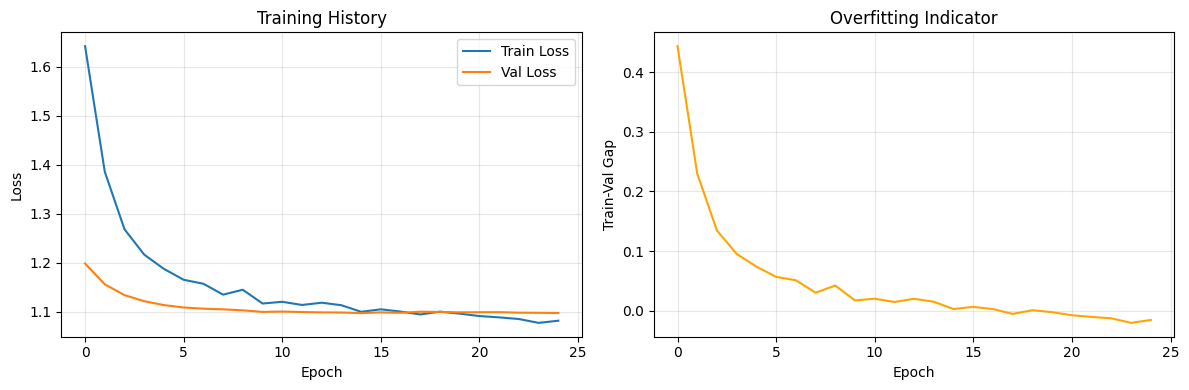

In [63]:
import matplotlib.pyplot as plt

def plot_training_history(model):
    """Визуализация кривых обучения"""
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(model.history['loss'], label='Train Loss')
    if model.history['val_loss']:
        plt.plot(model.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    if model.history['val_loss']:
        # Gap между train и val loss как индикатор переобучения
        gap = [t - v for t, v in zip(model.history['loss'], model.history['val_loss'])]
        plt.plot(gap, color='orange')
        plt.xlabel('Epoch')
        plt.ylabel('Train-Val Gap')
        plt.title('Overfitting Indicator')
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Пример использования
plot_training_history(nn_multi)